# Módulo 4 — Python para Preparação dos Dados
## Base PRF 2025 agrupada por ocorrência

**Entrega:** notebook + duas bases (`base_analitica_prf_2025.csv` e `base_modelavel_prf_2025.csv`) + README

**Onde o módulo se encaixa no CRISP-DM:** fase principal de *Preparação dos Dados*, revisitando também a *Compreensão dos Dados* e preparando o terreno para Modelagem, Avaliação e Comunicação.

**Produto oficial do módulo:**
- Notebook executável
- Base analítica completa
- Base modelável sem data leakage
- README e decisões de tratamento


> **Nota sobre esta execução:** este notebook foi executado com a base real
> `dados_abertos_prf-datatran2025.csv` (dados abertos da PRF, ano de 2025).
> A base traz colunas extras em relação ao roteiro original (`id`, `sentido_via`,
> `latitude`, `longitude`, `regional`, `delegacia`, `uop`), que são preservadas na
> base analítica sem interferir nas etapas de tratamento. O campo `km` chega com
> vírgula decimal (padrão brasileiro), por isso a Etapa 15 foi levemente adaptada
> para normalizar `,` para `.` antes da conversão numérica.

## Sessão 1 — Abertura, ambiente de trabalho e primeira leitura da base

### Bloco 1 — Preparação do ambiente de trabalho
#### Etapa 4 — Importar bibliotecas e configurar ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


#### Etapa 5 — Criar estrutura de pastas

In [2]:
RAIZ = Path(".")
PASTAS = [
    "dados_brutos", "dados_tratados", "notebooks", "sql",
    "dashboards", "relatorios", "apresentacao", "logs"
]
for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)


Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


#### Etapa 6 — Definir parâmetros do projeto

In [3]:
ARQUIVO_BRUTO = Path("dados_brutos/acidentes2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"


### Bloco 2 — Leitura e primeira inspeção da base
#### Etapa 7 — Ler o CSV da PRF com fallback de encoding

In [4]:
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")
            return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")
    raise ultimo_erro

df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head()


Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


#### Etapa 8 — Padronizar nomes das colunas

In [5]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")

df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Compatibilização de grafias possíveis
renomear = {"condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

print(df.columns.tolist())


['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


#### Etapa 9 — Conferir colunas esperadas

In [6]:
colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
    "causa_acidente", "tipo_acidente", "classificacao_acidente",
    "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via",
    "uso_solo", "pessoas", "mortos", "feridos_leves",
    "feridos_graves", "feridos", "veiculos"
]

faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)
if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")


Colunas faltantes: []


#### Etapa 10 — Retrato inicial da base

In [7]:
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
display(df.head())
display(df.sample(5, random_state=42))


Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


### Bloco 3 — Diagnóstico de qualidade dos dados
#### Etapa 11 — Tipos de dados e memória

In [8]:
df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)
display(resumo_tipos)


<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

,tipo,qtd_colunas
0,str,20
1,int64,10


#### Etapa 12 — Diagnóstico de valores ausentes

In [9]:
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)

display(nulos[nulos["qtd_nulos"] > 0])


,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


#### Etapa 13 — Diagnóstico e remoção de duplicidades

In [10]:
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)

if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas. Nova dimensão:", df.shape)


Duplicidades exatas: 0


#### Etapa 14 — Cardinalidade das categorias

In [11]:
categoricas = df.select_dtypes(include="object").columns

cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))


/tmp/ipykernel_538/4126746856.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include="object").columns


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


## Sessão 2 — Transformações e variáveis derivadas

### Bloco 4 — Transformações e criação de variáveis derivadas
#### Etapa 15 — Converter colunas numéricas

In [12]:
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
]

# Adaptação para a base real: campos como 'km' vêm com vírgula decimal
# (ex.: "546,2"), então normalizamos para ponto antes de converter.
for coluna in colunas_numericas:
    if coluna in df.columns:
        # (cobre "object", "string" e o dtype "str" nativo do pandas >= 3.0)
        if str(df[coluna].dtype) in ("object", "string", "str"):
            df[coluna] = df[coluna].astype(str).str.replace(",", ".", regex=False)
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)


br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


#### Etapa 16 — Tratar datas e criar variáveis temporais

In [13]:
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head())


,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


#### Etapa 17 — Tratar horário e criar turno

In [14]:
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()
if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
    ).dt.hour

def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)
display(df[["horario", "hora", "turno"]].head())


,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


#### Etapa 18 — Criar faixa horária

In [15]:
def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"
    inicio = int(hora // 3) * 3
    fim = inicio + 2
    return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())


faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

#### Etapa 19 — Padronizar textos

In [16]:
colunas_texto = df.select_dtypes(include="object").columns

for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )
    df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

print("Colunas textuais padronizadas:", len(colunas_texto))


/tmp/ipykernel_538/3361440889.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


Colunas textuais padronizadas: 20


#### Etapa 20 — Tratar nulos categóricos

In [17]:
categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "classificacao_acidente", "dia_semana"
]

for coluna in categoricas_importantes:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna("IGNORADO")

print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))


uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


#### Etapa 21 — Tratar nulos numéricos de contagem

In [18]:
contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veiculos"]

for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())


mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


## Sessão 3 — Variável-alvo e indicadores de gravidade

### Bloco 5 — Variável-alvo e indicadores de gravidade
#### Etapa 22 — Criar variável-alvo `acidente_fatal`

In [19]:
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)


,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


#### Etapa 23 — Validar logicamente o alvo

In [20]:
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."


Violações da regra do alvo: 0


#### Etapa 24 — Criar indicadores de gravidade

In [21]:
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
    1,
    0
)
df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)

display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())


,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


#### Etapa 25 — Criar BR formatada e chave de localidade

In [22]:
def formatar_br(valor):
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)
df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)

display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())


,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


#### Etapa 26 — Checagens rápidas após transformação

In [23]:
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(df["acidente_fatal"].sum()),
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),
    "total_mortos": int(df["mortos"].sum()),
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}
checagens


{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

#### Etapa 27 — Ranking rápido de categorias

In [24]:
def ranking_categoria(base, coluna, n=10):
    return (
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna)
        .reset_index(name="qtd")
    )

display(ranking_categoria(df, "causa_acidente", 10))
display(ranking_categoria(df, "tipo_acidente", 10))


,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


#### Etapa 28 — Taxa fatal por categoria

In [25]:
def taxa_fatal_por_categoria(base, coluna, min_registros=30):
    tab = base.groupby(coluna).agg(
        qtd_acidentes=("acidente_fatal", "size"),
        qtd_fatais=("acidente_fatal", "sum"),
        taxa_fatal=("acidente_fatal", "mean")
    ).reset_index()
    tab = tab[tab["qtd_acidentes"] >= min_registros]
    return tab.sort_values("taxa_fatal", ascending=False)

display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))


,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


#### Etapa 29 — Gráfico simples de conferência

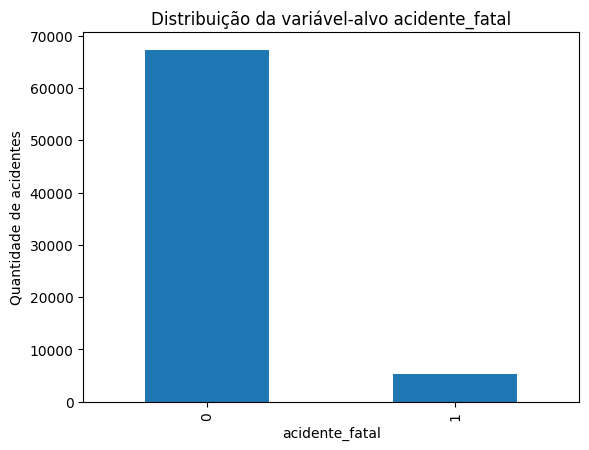

In [26]:
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
plt.show()


## Sessão 4 — Construção das bases finais e documentação

### Bloco 6 — Construção das duas bases (analítica e modelável)
#### Etapa 30 — Conceito de base analítica completa
- Usada para EDA e Power BI
- Pode conter mortos e feridos
- Pode conter indicadores derivados
- Foco em descrição e comunicação


#### Etapa 31 — Gerar base analítica completa

In [27]:
base_analitica = df.copy()
print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())


Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


#### Etapa 32 — Conceito de base modelável
- Usada na árvore de decisão
- Apenas variáveis explicativas
- Inclui `acidente_fatal` como alvo
- Exclui variáveis derivadas do desfecho


#### Etapa 33 — Selecionar variáveis modeláveis

In [28]:
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre",
    "dia_semana", "dia_semana_num", "fim_de_semana",
    "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
    "acidente_fatal"
]
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()
print("Base modelável:", base_modelavel.shape)


Base modelável: (72529, 19)


#### Etapa 34 — Verificar data leakage

In [29]:
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave",
    "classificacao_acidente"
]

def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]
    if presentes:
        raise ValueError(f"Data leakage detectado: {presentes}")
    return "OK — nenhuma variável proibida encontrada."

verificar_data_leakage(base_modelavel, variaveis_proibidas)


'OK — nenhuma variável proibida encontrada.'

#### Etapa 35 — Tratamento final de nulos na base modelável

In [30]:
for coluna in base_modelavel.columns:
    if coluna == "acidente_fatal":
        continue
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

print(base_modelavel.isna().sum().sort_values(ascending=False).head())


uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


#### Etapa 36 — Exportar bases tratadas

In [31]:
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)


Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv


#### Etapa 37 — Reabrir arquivos exportados

In [32]:
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)


Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


### Bloco 7 — Documentação do projeto
#### Etapa 38 — Gerar dicionário das variáveis criadas

In [33]:
linhas_dic = [
    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"},
    {"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
    {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso": "analise/modelagem"},
    {"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso": "analise/dashboard"},
]

dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
display(dicionario)


,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


#### Etapa 39 — Registrar decisões de tratamento

In [34]:
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(ARQUIVO_DECISOES)


logs/decisoes_tratamento_modulo4.md


#### Etapa 40 — Criar README do projeto

In [35]:
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de decisão explicável.

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente derivadas do desfecho.
"""

ARQUIVO_README.write_text(readme, encoding="utf-8")
print("README criado:", ARQUIVO_README)


README criado: README.md


#### Etapa 41 — Resumo final da preparação

In [36]:
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])
display(resumo_final)


,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833


## Sessão 5 — Boas práticas, erros comuns e encerramento

### Bloco 8 — Boas práticas e erros comuns

**Etapa 47 — Boas práticas em notebooks:** executar do início ao fim, células em ordem lógica, comentários curtos, sem caminhos pessoais fixos.

**Etapa 48 — Erros comuns na leitura do CSV:** separador errado, encoding errado, colunas em uma única coluna, acentuação quebrada.

**Etapa 49 — Erros comuns no alvo:** inverter 0 e 1, usar feridos no lugar de mortos, não tratar nulos, não conferir distribuição.

**Etapa 50 — Erros comuns de data leakage:** manter mortos/total_vitimas/indice_gravidade na base modelável, usar classificação do acidente sem crítica.

### Bloco 9 — Checklist, critérios de qualidade e conexões com os próximos módulos

**Etapa 51 — Checklist final da entrega**
- [x] Notebook executa sem erro
- [x] Bases em `dados_tratados`
- [x] README criado
- [x] Decisões registradas
- [x] Leakage ausente (verificado na Etapa 34)

**Etapa 52 — Critérios de qualidade:** correção técnica, reprodutibilidade, documentação, separação correta das bases, prevenção de vazamento.

**Etapa 53 — Conexão com Módulo 5:** a base analítica alimentará a EDA, com indicadores explorados e cruzamentos com `acidente_fatal`.

**Etapa 54 — Conexão com Módulo 6:** o Power BI usará a base analítica; os filtros dependem das variáveis padronizadas (UF, BR, município, mês).

**Etapa 55 — Conexão com Módulo 7:** a base modelável alimentará a árvore de decisão, sem data leakage, com foco em explicabilidade.

**Etapa 56 — Fechamento do Módulo 4:** dados preparados com rigor, duas bases com finalidades distintas, notebook reprodutível, documentação pronta para avaliação.
